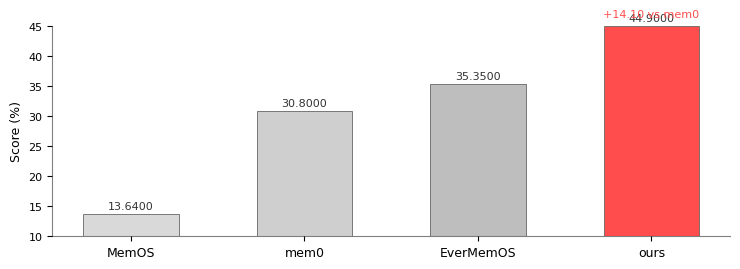

In [3]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["MemOS", "mem0", "EverMemOS", "ours"]
values = [13.64, 30.80, 35.35, 44.90]

x = np.arange(len(labels))

# Colors follow the reference: light grays for baselines, red highlight for ours
gray_shades = ["#D9D9D9", "#CFCFCF", "#BEBEBE"]
colors = gray_shades + ["#FF4D4D"]

fig, ax = plt.subplots(figsize=(7.5, 2.8))
bars = ax.bar(x, values, width=0.55, color=colors, edgecolor="#666666", linewidth=0.6)

ax.set_xticks(x, labels, fontsize=9)
ax.set_ylabel("Score (%)", fontsize=9)
ax.set_ylim(10, 45)

# Value labels
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.4f}",
            ha="center", va="bottom", fontsize=8, color="#333333")

# Highlight annotation for ours
ours_idx = labels.index("ours")
ax.text(ours_idx, values[ours_idx] + 1.2, "+14.10 vs mem0",
        ha="center", va="bottom", fontsize=8, color="#FF4D4D")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.5)
ax.spines["bottom"].set_alpha(0.5)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


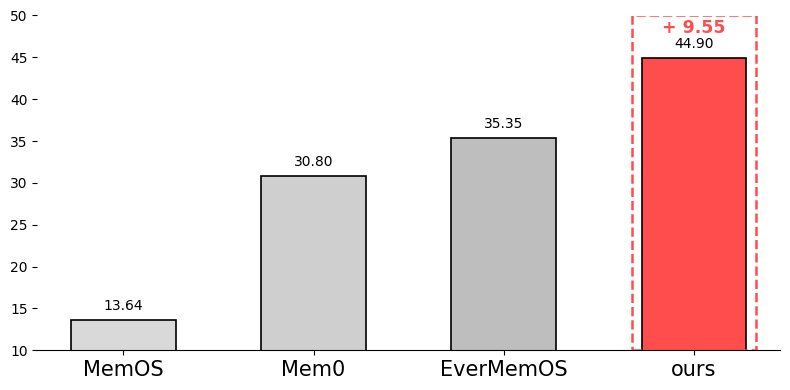

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Data and labels
labels = ["MemOS", "Mem0", "EverMemOS", "ours"]
values = [13.64, 30.80, 35.35, 44.90]

# Color palette: Gradients from light gray to red for our model (ours)
gray_shades = ["#D9D9D9", "#CFCFCF", "#BEBEBE"]
highlight_color = "#FF4D4D"
colors = gray_shades + [highlight_color]

# Define x locations for each label
x = np.arange(len(labels))

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

# Create the bar chart with edge coloring for professionalism
bars = ax.bar(x, values, width=0.55, color=colors, edgecolor="black", linewidth=1.2)

# Adjust tick labels, y-axis, and other settings
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=15)
# ax.set_ylabel("Score (%)", fontsize=15)
ax.set_ylim(10, 50)

# Add value labels above each bar
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.8, f"{value:.2f}",
            ha="center", va="bottom", fontsize=10, color="black")

# Highlight the 'ours' bar with a red box and annotation
ours_idx = labels.index("ours")
ax.text(ours_idx, values[ours_idx] + 2.5, f"+ 9.55", 
        ha="center", va="bottom", fontsize=12.5, color=highlight_color, fontweight='bold')
ax.add_patch(plt.Rectangle((bars[ours_idx].get_x() - 0.05, 10), bars[ours_idx].get_width() + 0.1, 40,
                           linewidth=1.8, edgecolor=highlight_color, facecolor='none', linestyle='--'))

# Remove unnecessary spines and customize grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
# ax.spines["left"].set_alpha(0.6)
# ax.spines["bottom"].set_alpha(0.6)
# ax.tick_params(axis="y", labelsize=13)


# Optionally, add a grid for better readability (subtle background grid)
# ax.grid(axis='y', linestyle='--', linewidth=0.6, color='gray', alpha=0.4)

# Tight layout to adjust labels and avoid clipping
plt.tight_layout()
plt.show()


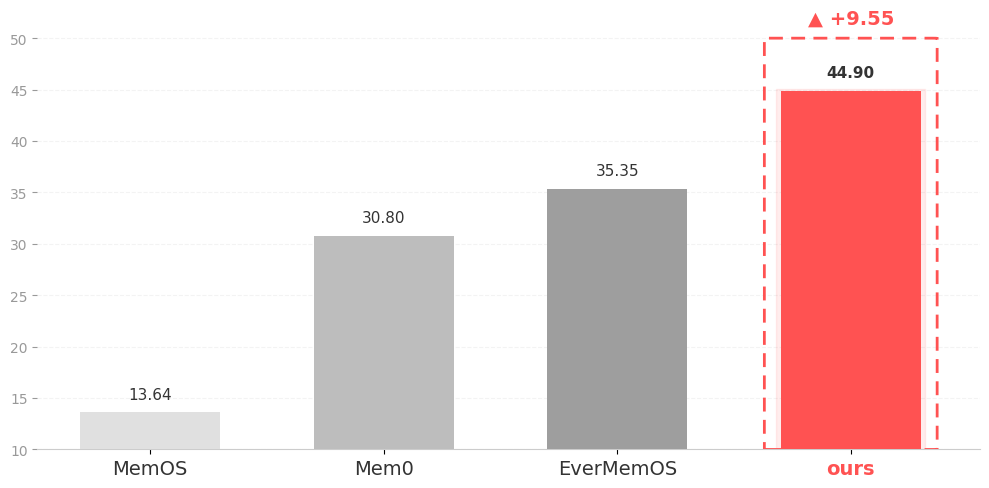

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# --- 数据准备 ---
labels = ["MemOS", "Mem0", "EverMemOS", "ours"]
values = [13.64, 30.80, 35.35, 44.90]
improvement = values[3] - values[2]

# --- 现代配色 ---
# 使用更有层次感的灰色和具有活力的珊瑚红
colors = ["#E0E0E0", "#BDBDBD", "#9E9E9E", "#FF5252"]
text_color = "#333333"
highlight_color = "#FF5252"

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
fig.patch.set_facecolor('white') # 背景纯白

x = np.arange(len(labels))
width = 0.6

# --- 绘制柱状图 ---
# 使用普通的bar，但我们可以通过特定的样式使其看起来更现代
bars = ax.bar(x, values, width=width, color=colors, edgecolor="none", zorder=3)

# 为 "ours" 添加特殊的阴影效果（通过在下方画一个略大的淡色矩形模拟）
ours_idx = 3
ax.add_patch(plt.Rectangle((ours_idx - width/2 - 0.02, 10), width + 0.04, values[ours_idx]-9.8, 
                           color=highlight_color, alpha=0.1, zorder=2))

# --- 优化数值标注 ---
for i, bar in enumerate(bars):
    height = bar.get_height()
    font_weight = 'bold' if i == ours_idx else 'normal'
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{height:.2f}",
            ha="center", va="bottom", fontsize=11, color=text_color, fontweight=font_weight)

# --- 突出优势：精致的虚线框和标注 ---
# 使用圆角虚线框
padding = 0.1
rect = FancyBboxPatch((ours_idx - width/2 - padding/2, 10), width + padding, 40,
                      boxstyle="round,pad=0.02", linewidth=2, linestyle=(0, (5, 3)),
                      edgecolor=highlight_color, facecolor='none', zorder=4)
ax.add_patch(rect)

# 增加 "+ 9.55" 的气泡感标注
ax.text(ours_idx, 51, f"▲ +{improvement:.2f}", 
        ha="center", va="bottom", fontsize=14, color=highlight_color, fontweight='black')

# --- 界面美化 ---
# 隐藏多余边框
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

# 设置Y轴范围和刻度
ax.set_ylim(10, 52)
ax.tick_params(axis='y', colors='#999999', labelsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=14, fontweight='medium', color=text_color)

# 添加水平网格线（极简风格）
ax.yaxis.grid(True, linestyle='--', which='major', color='#EEEEEE', alpha=0.7, zorder=0)

# 让 "ours" 标签加粗变色
ax.get_xticklabels()[ours_idx].set_fontweight('bold')
ax.get_xticklabels()[ours_idx].set_color(highlight_color)

plt.tight_layout()
plt.show()